**Evidence-coverage report: behavioral + MEC/LEC/HPC diagnostic slice.**
This report evaluates the current report-backed evidence for TEM-style
structural memory by inspecting behavioural prediction, MEC/g structural
states, LEC/x content states, and HPC/p binding-related states. The current
evidence supports a diagnostic slice of the g/x/p factorisation, while
training dynamics, formal remapping/generalisation, ablations, shuffle
baselines, and explicit retrieval-pathway analyses remain open.


| Field              | Value                               |
| ------------------ | ----------------------------------- |
| Model family       | TEM v1, TEM v2, EHP v1, EHP v2      |
| Task               | Arena (next-observation prediction) |
| Created            | 2026-06-02T07:29:25Z                |
| Device / precision | CPU (diagnostic regime)             |
| Seed               | Not recorded in provenance          |


Available reports and figures:


In [6]:
from ehc_sn.reporting import open_report
from IPython.display import Image, Markdown, display
from notebooks.utils import display_mermaid

# Report paths
TEM_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n1"
TEM_V2_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n1"

# Load reports
tem_v1_report = open_report(TEM_V1_REPORT_PATH)
tem_v2_report = open_report(TEM_V2_REPORT_PATH)

# Display report summaries for tem_v1
print("TEM v1 report summary:")
print(f"  - report:   {tem_v1_report.root}")
print(f"  - metrics:  {tem_v1_report.summary()['metric_count']}")
print(f"  - metrics:  {tem_v2_report.summary()['metric_count']}")

# Display report summaries for tem_v1
print("TEM v2 report summary:")
print(f"  - report:   {tem_v2_report.root}")
print(f"  - figures:  {tem_v1_report.summary()['figure_count']}")
print(f"  - figures:  {tem_v2_report.summary()['figure_count']}")

TEM v1 report summary:
  - report:   /home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n1
  - metrics:  6
  - metrics:  6
TEM v2 report summary:
  - report:   /home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n1
  - figures:  16
  - figures:  16


# Scientific Question

**Does the model learn a reusable structural representation of
environment topology, separable from sensory content, in the sense
described by the Tolman–Eichenbaum Machine (Whittington et al., 2020)?**

We inspect four internal pathways to evaluate evidence at
four levels:

| Level                        | Evidence required                                                |
| ---------------------------- | ---------------------------------------------------------------- |
| **Behavioral**               | Does each pathway achieve expected accuracy given its data flow? |
| **Predictive**               | Are generative predictions better on revisits than first visits? |
| **Latent geometry**          | Does MEC `g` encode structure, LEC `x` encode content?           |
| **Neural-style diagnostics** | Do units show place-like, grid-like, or landmark-like tuning?    |


# Task and Benchmark — Arena Replay

Arena is a structural-navigation task where an agent navigates a 2-D grid
dungeon topology. At each step the agent occupies one passable cell and
observes a categorical **observation ID** (a unique integer per cell).
The agent can move in four cardinal directions (↑↓←→) or stop (idle action).

**Navigation**: An agent starts at a random location and navigates the
environment for a fixed number of steps. The trajectory is randomly generated
and used to produce a sequence of observations and actions.

**Prediction task:** At each step $t$, the model receives the action taken at
$t-1$, and must predict the observation ID at the current step $t$.

**reconstruction**: The model, also receives the current observation ID as
input, its purpose is not to use it for prediction but so it can store it in
memory and retrieve it in the future.

**Revisit definition:** A **revisit** occurs when the agent occupies a cell
it has already visited earlier in the same episode.

Note that the model does not perform an action, but receives the action taken by
the agent as input. This design choice allows us to evaluate the model's ability
to predict the next observation ID based on its internal representation of the
environment and the agent's actions, without confounding the results with the
model's own action selection process.


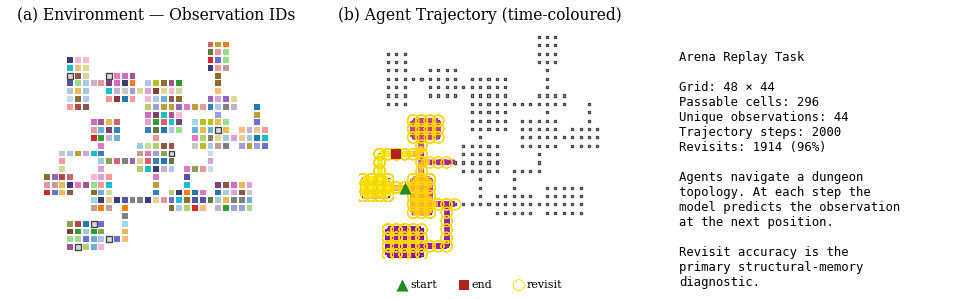

In [9]:
# Arena Task Overview (paradigm context; same dataset for both models)
overview_entry = tem_v1_report.figure_entry("arena_task_layout", preferred_format="png")
if overview_entry:
    abs_path = tem_v1_report.root / overview_entry.path
    display(Image(filename=str(abs_path)))
else:
    print("arena_task_layout not available.")

> Figure 1: Example episode in the Arena task. Panel (a) shows the dungeon topology, with free cells coloured by their unique observation ID. Panel (b) shows the agent's trajectory through the environment, coloured by time. Revisits are highlighted with yellow circles, indicating when the agent returns to a previously visited cell.


# Model Internals Inspected

The TEM architecture separates structural knowledge (MEC-like) from sensory
content (LEC-like) via a conjunctive hippocampal (HPC) binding. This report
inspects the following internal variables and pathways.

See §4 (How the Three Prediction Pathways Work) for a detailed description
of the data flow through inference, retrieved, and ancestral pathways.

| System    | Scientific role                    | Report-facing name            |
| --------- | ---------------------------------- | ----------------------------- |
| LEC (`x`) | Sensory-content state              | LEC content-state activity    |
| MEC (`g`) | Structural state, path integration | MEC structural state          |
| HPC (`p`) | Structure-content binding          | HPC binding/place-like state  |
| Output    | Behavioral prediction (3 pathways) | Prediction argmax per pathway |
| Target    | Ground-truth observation sequence  | Target observation IDs        |


## How the Three Prediction Pathways Work

TEM based models produce three observation predictions at each step $t$.
All three predict the **same target** — `observation[t]` — but differ
in which inputs they receive. Understanding the data flow is critical for
interpreting pathway-specific accuracy.


### The key variables

At each step `t`, the model receives:

- `observation[t]` — what the agent sees now (e.g. wall colors in this room)
- `previous_action[t-1]` — the action taken to arrive here (N/S/E/W)

From these, it computes five internal codes:

| Internal Code      | Estimation                               | Prediction meaning                             |
| ------------------ | ---------------------------------------- | ---------------------------------------------- |
| $g_{prior}[t]$     | $integrate(g[t-1], action)$              | Where, based on where I was and how I moved    |
| $g_{post}[t]$      | $correct(g_{prior}[t], sensory_recall)$  | Where, did I see this observation here before? |
| $p_{retrieved}[t]$ | $attractor(g_{post}[t], memory)$         | Experience from my visually corrected location |
| $p_{prior}[t]$     | $attractor(g_{prior}[t], memory)$        | Experience predicted from memory               |
| $p_{post}[t]$      | $activate(g_{post}[t] ⊙ observation[t])$ | Experience obtained from what I see            |

And three prediction pathways:


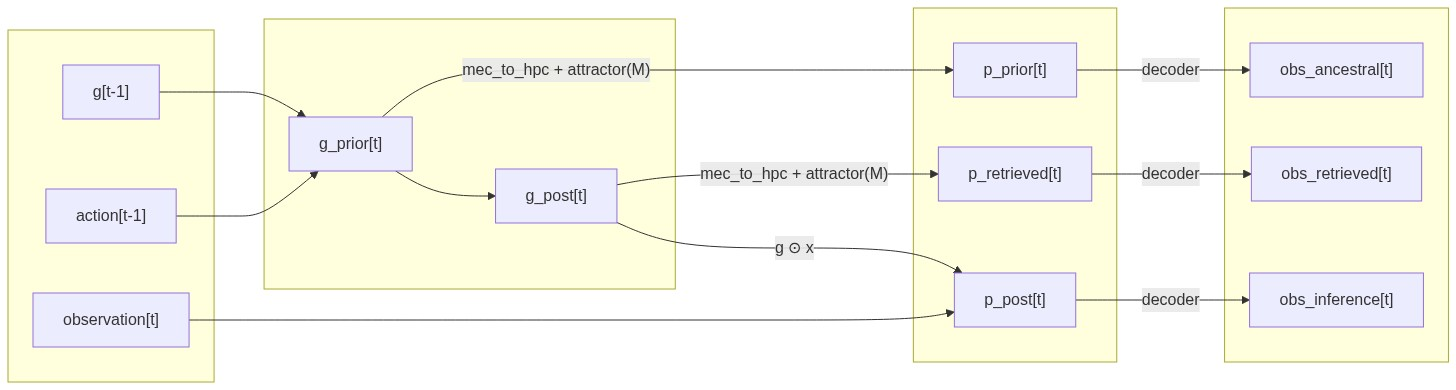

In [10]:
diagram = """
graph LR
    subgraph " "
        G0["g[t-1]"]
        ACT["action[t-1]"]
        OBS["observation[t]"]
    end

    subgraph " "
        G_PRIOR["g_prior[t]"]
        G_POST["g_post[t]"]
    end

    subgraph " "
        P_RET["p_retrieved[t]"]
        P_PRIOR["p_prior[t]"]
        P_POST["p_post[t]"]
    end

    subgraph " "
        ANC["obs_ancestral[t]"]
        RET["obs_retrieved[t]"]
        INF["obs_inference[t]"]
    end

    G0 --> G_PRIOR
    ACT --> G_PRIOR

    G_PRIOR --> G_POST

    G_PRIOR -->|"mec_to_hpc + attractor(M)"| P_PRIOR
    G_POST  -->|"mec_to_hpc + attractor(M)"| P_RET
    G_POST -->|"g ⊙ x"| P_POST
    OBS --> P_POST

    P_PRIOR -->|"decoder"| ANC
    P_RET   -->|"decoder"| RET
    P_POST  -->|"decoder"| INF
"""
display_mermaid(diagram)

### The observation leak in the retrieved pathway

The retrieved pathway has an indirect observation leak. The sensory-recall
step uses `observation[t]` to query the inverse Hebbian memory:

```text
p_sensory_read = hpc.recall(
    query = lec_to_hpc(observation[t]),   ← current observation
    memory = M_inverse
)
```

This recalled place code corrects `g_prior[t]` → `g_post[t]`, which then
queries the forward memory for `p_retrieved`. The observation enters
through the **memory**, not through the direct `g ⊙ x` conjunction.


### Why inference accuracy = 1.0 is trivial

Since `observation[t]` enters the place code directly via `g ⊙ x`,
decoding it back is **autoencoding**. 100% inference accuracy means the
LEC → HPC → inverse → decoder pipeline doesn't lose information when
storing the current observation. It does **not** mean the model has learned
a cognitive map.


### Why ancestral accuracy can exceed random chance

The Arena has a **fixed mapping**: position → observation. Room (3,7)
always has the same wall color. The decoder learns this mapping during
training. Ancestral accuracy reflects **path integration quality** plus
learned **position → observation** knowledge — not memory retrieval.

On validation episodes with the same Arena layout, ancestral accuracy
remains above chance because the structural mapping is invariant. A true
generalization test would remap observations to new positions, breaking
the learned mapping.


### What actually tests memory

The **revisit-conditioned metrics** (`accuracy_revisit` for ancestral and
retrieved) isolate the memory contribution. On a first visit, ancestral
prediction has no memory to rely on, accuracy reflects random chance. When
memory is available (revisit), ancestral prediction can rely on path integration
to retrieve the correct experience. The delta between first-visit and
revisit accuracy for ancestral/retrieved pathways is the primary
memory-quality signal.


# Behavioral Performance

The primary metrics for Arena benchmark are the three prediction pathways
(inference, retrieved, ancestral) on both first-visit and revisit steps.
Like in generative models, the pathways differ in which internal codes
they use as input to predict `observation[t]`:

| Pathway       | `Observation[t]` | Accuracy meaning                           |
| ------------- | ---------------- | ------------------------------------------ |
| **Inference** | Yes - Directly   | **Autoencoding** — Correct memory creation |
| **Retrieved** | Yes - Indirectly | **Semi-generative** — todo                 |
| **Ancestral** | No               | **Pure generative** — Correct prediction   |

**Key insight:** `accuracy_all` (aggregated over all steps) can be
misleading. Inference accuracy is trivially 1.0 because the pathway
autoencodes the current observation. Ancestral accuracy can exceed
random chance in validation because the Arena's position→observation
mapping is fixed and learned, not because memory generalizes. The most
informative metric is the **delta between first-visit and revisit
ancestral accuracy** — this isolates the Hebbian memory contribution.

**Chance baseline:** Uniform random guessing. For example, over 45 observation
classes it yields $1/45 \approx 0.022$.


In [14]:
# Display metrics grouped by prediction pathway from both ReportRuns.
# Pathway-specific retrieval and ancestral accuracy are evaluated in §5.

import pandas as pd

PATHWAY_MAP = {
    "Ancestral": {
        "all": "accuracy_ancestral_all",
        "revisit": "accuracy_ancestral_revisit",
    },
    "Retrieved": {
        "all": "accuracy_retrieved_all",
        "revisit": "accuracy_retrieved_revisit",
    },
    "Inference": {
        "all": "accuracy_inference_all",
        "revisit": "accuracy_inference_revisit",
    },
}

reports = [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]

rows = []
for run_name, report in reports:
    for pathway, metric_keys in PATHWAY_MAP.items():
        all_val = None
        revisit_val = None
        for record in report.metrics():
            if record.metric == metric_keys["all"]:
                all_val = record.value
            elif record.metric == metric_keys["revisit"]:
                revisit_val = record.value
        rows.append(
            {
                "Run": run_name,
                "Pathway": pathway,
                "All steps": all_val,
                "Revisit steps": revisit_val,
            }
        )

table = pd.DataFrame(rows).set_index(["Run", "Pathway"])
display(table)

All steps  Revisit steps
Run    Pathway                            
TEM v1 Ancestral     0.1810       0.188088
       Retrieved     0.2650       0.275862
       Inference     0.9945       0.994253
TEM v2 Ancestral     0.0110       0.010449
       Retrieved     0.0110       0.010449
       Inference     0.9535       0.951411

> Table 1: Pathway-level accuracy metrics for TEM v1 and TEM v2. Each pathway provides a different view of model behaviour.


Metric definitions:

- `accuracy_ancestral_all` — prediction from structural state alone over all steps.
- `accuracy_ancestral_revisit` — prediction from structural state alone on revisit steps. This is the **primary benchmark metric** for `arena-struct`.
- `accuracy_retrieved_all` — prediction from the memory retrieval pathway over all steps.
- `accuracy_retrieved_revisit` — prediction from the memory retrieval pathway on revisit steps.
- `accuracy_inference_all` — inference/recognition-assisted prediction over all steps. **Diagnostic metric**: the inference pathway has access to current sensory information, so high values reflect autoencoding quality rather than structural prediction.
- `accuracy_inference_revisit` — inference-pathway accuracy on revisit steps. **Diagnostic metric**, not the primary structural benchmark score.
  Metric values are loaded dynamically from report artifacts. Pathway-specific discussion is in §5 (Episodic Retrieval).


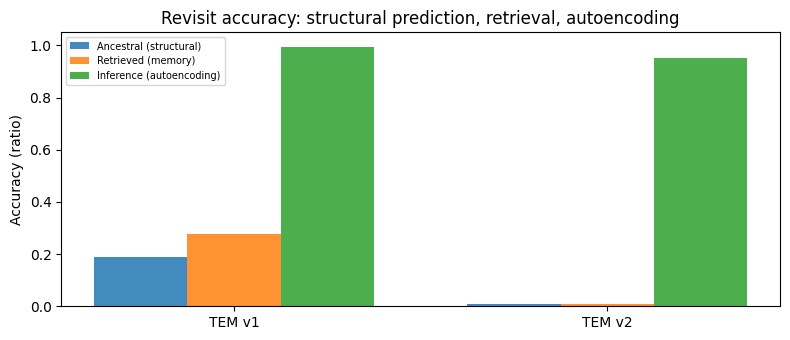

In [13]:
# --- Benchmark comparison plot ----------------------------------------------
# Grouped bar plot: revisit accuracy by pathway and model.
# Ancestral is left-most (strictest structural test);
# inference is right-most (autoencoding, trivially high).

import matplotlib.pyplot as plt
import numpy as np

# Reuse the table DataFrame built above for the bar plot.
plot_df = table.reset_index()

ancestral_mask = plot_df["Pathway"] == "Ancestral"
retrieved_mask = plot_df["Pathway"] == "Retrieved"
inference_mask = plot_df["Pathway"] == "Inference"

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(plot_df["Run"].unique()))
width = 0.25

anc_vals = plot_df.loc[ancestral_mask, "Revisit steps"].values
ret_vals = plot_df.loc[retrieved_mask, "Revisit steps"].values
inf_vals = plot_df.loc[inference_mask, "Revisit steps"].values

ax.bar(x - width, anc_vals, width, label="Ancestral (structural)", alpha=0.85)
ax.bar(x, ret_vals, width, label="Retrieved (memory)", alpha=0.85)
ax.bar(x + width, inf_vals, width, label="Inference (autoencoding)", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Run"].unique())
ax.set_ylabel("Accuracy (ratio)")
ax.set_title("Revisit accuracy: structural prediction, retrieval, autoencoding")
ax.legend(fontsize=7)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

> Figure X: Revisit accuracy by prediction pathway. The ancestral (structural) pathway tests whether the model can predict from learned structural state alone. The retrieved pathway tests memory retrieval. The inference (autoencoding) pathway has direct access to current sensory information and should not be treated as a structural prediction score.


### How to read this comparison

High values indicate stronger performance under the displayed metric definition. Low values indicate weaker performance under that metric, but they do not by themselves identify the failing mechanism.

High inference accuracy reflects autoencoding quality, not structural prediction — the inference pathway has direct access to the current observation via the `g ⊙ x` conjunction.

A gap between `accuracy_inference_revisit` and `accuracy_ancestral_revisit` suggests that correct revisit behavior may not be driven by structural-state prediction alone — sensory or memory information contributes beyond structure.

A gap between `accuracy_retrieved_revisit` and `accuracy_ancestral_revisit` separates memory-based prediction from structure-only prediction.

Similar values across pathways suggest that the selected evaluator does not expose a large separation between task performance and pathway-specific performance, or that the model handles them similarly.

Differences across report runs should only be interpreted when the runs share compatible task splits, evaluator versions, metric definitions, and runtime conditions.

### Validity notes

This comparison is valid only for report runs produced under compatible benchmark conditions. Runs with different dataset splits, different numbers of evaluated cases, different evaluator versions, different metric definitions, or incompatible runtime settings should not be silently compared as equivalent.

The benchmark metrics summarize behavior. They do not explain mechanism. Mechanistic claims require the diagnostic sections (§§2–5) that inspect traces, pathway-specific predictions, latent states, or module-specific representations.

When a metric is unavailable, the table shows the missing value explicitly rather than treating the model as evaluated.


## Arena Prediction Overlays

Ground-truth observation sequence (`gt`) vs. three prediction pathways.
All three predict the **same target** — `observation[t]` — but differ in
which inputs they have access to. See §4 (How the Three Prediction Pathways
Work) for the full data-flow description.

| Prediction pathway | Scientific role                                                                                            | Uses `observation[t]`?                 |
| ------------------ | ---------------------------------------------------------------------------------------------------------- | -------------------------------------- |
| Inference          | **Autoencoded reconstruction** — the current observation enters the place code via `g ⊙ x`                 | **Yes**, directly                      |
| Retrieved          | **Semi-generative** — grid is corrected by sensory-cued memory recall, then attractor reads forward memory | **Indirectly**, through inverse memory |
| Ancestral          | **Pure generative** — path integration only, no observation at any stage                                   | **No**                                 |

Below is the first case's arena_prediction_overlay figure from each ReportRun.


TEM v1 — arena_prediction_overlay (case=arena_n1)


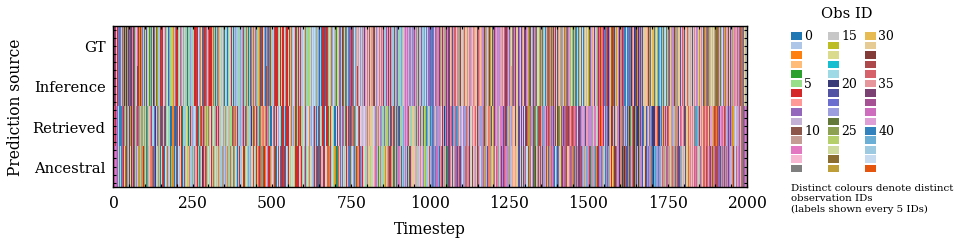

TEM v2 — arena_prediction_overlay (case=arena_n1)


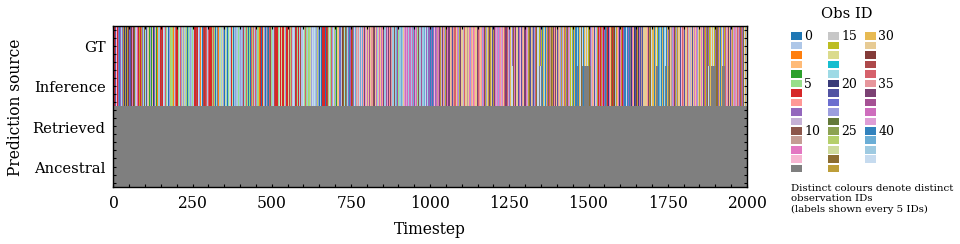

In [11]:
# --- Arena prediction overlay: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("arena_prediction_overlay", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: arena_prediction_overlay not available.")

> Figure 2: Prediction overlays for the first case in each ReportRun. Each
> sequence shows the predicted observation ID (colour) for each pathway
> (inference, retrieved, ancestral) compared to the ground-truth (GT)
> observation ID at each step. Inference should match GT perfectly
> (autoencoding). Discrepancies in the ancestral and retrieved pathways,
> particularly on revisit steps, indicate where the Hebbian memory and
> path integration fail to produce posterior-quality place codes.


# LEC / x Sensory-Content

The TEM implementation includes an explicit LEC stream that processes
observation embeddings before projection into HPC. In the
Tolman–Eichenbaum interpretation, this stream corresponds to the sensory/
content state $x$.

This section evaluates the LEC content stream in two ways. First, the
content-filtering diagnostic figure shows LEC content-state and
filtered-state per-unit activations across frequency bands, plus the
learned retention and input-mixing gate values annotated inside each
band label. Second, the content-vs-location contrast asks whether
LEC activity is organised more by sensory identity than by arena location,
and compares that organization against MEC/g and HPC/p.

Together, these figures test whether LEC acts as a content-state stream
rather than another spatial-map diagnostic.

### Variables inspected

Inputs inspected:

- `diagnostic/lec/sensory_code`: raw sensory code $c$ per frequency band
- `diagnostic/lec/filtered`: EMA-filtered LEC state per frequency band
- `lec_alpha_sigmoid`: learned retention gate $\alpha_f$ per band
- `lec_w_f_sigmoid`: learned input-mixing gate $\sigma(w_f)$ per band
- `t`: trajectory step (horizontal axis in activation panels)
- `f_k`: frequency band index (vertical grouping)
- `observation_id`, `location_id`: environment annotations used for RSA grouping

Typical shapes:

- Each band array: [time, n_units_per_band]
- Stacked matrix: [n_rows, time] after concatenating bands with NaN separators
- Plotted value: raw channel activation, not a decoded prediction.


## Content-state filtering

This is a **model-internal activation-flow diagnostic** for the sensory content stream — not a biological firing-rate raster. This section shows whether LEC units exhibit frequency-dependent activation structure and whether the filtering mechanism suppresses or enhances specific activation dimensions. It addresses whether the LEC stream shows content-related structure rather than undifferentiated activity.

**What to look for:** Inspect three properties across the transformation cascade. First, whether the sensory code (panel a) shows differentiated structure across frequency bands — different activation profiles across bands indicate that the sensory stream is not collapsed into a uniform code. Second, whether the EMA-filtered state (panel b) preserves or modifies those patterns relative to panel a — the $\alpha_f$ values annotate retention strength per band. Third, whether the final LEC cells (panel c) amplify or attenuate specific bands via $\sigma(w_f)$ — bands with $\sigma(w_f) \approx 0$ are effectively silenced. Pay attention to whether the learned gate parameters ($\alpha_f$, $\sigma(w_f)$) have moved from their initialization values, which would indicate training-shaped filtering.


TEM v1 — lec_content_filtering (case=arena_n1)


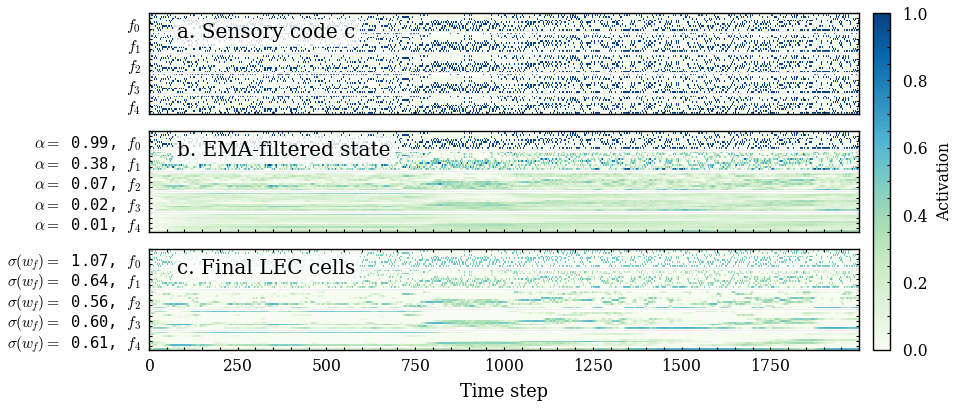

TEM v2 — lec_content_filtering (case=arena_n1)


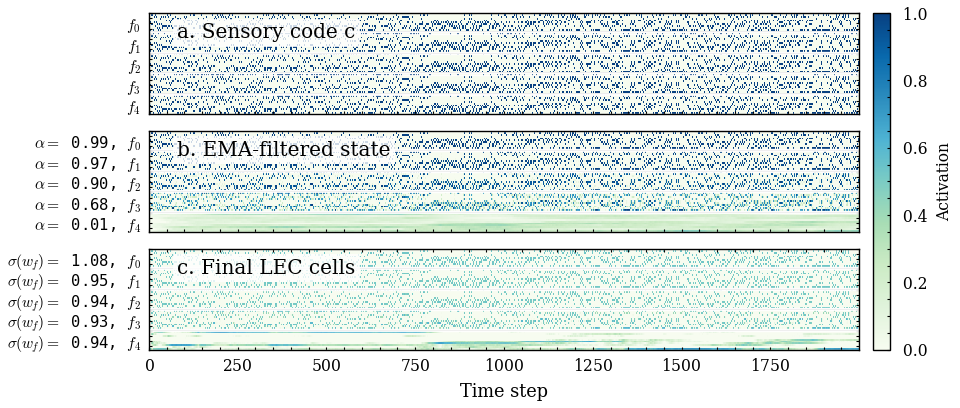

In [36]:
# --- LEC content filtering: first case from TEM v1 ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("lec_content_filtering", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: lec_content_filtering not available.")

> Figure 3: Content-filtering diagnostic figure for the LEC stream. Panel (a) shows the content-state activations per unit, grouped by frequency band. Panel (b) shows the filtered-state activations in the same row order. Panel (c) shows the filter effect, highlighting which activation dimensions are suppressed or enhanced by the frequency-dependent filtering. The learned gate parameters ($\alpha_f$, $w_f$) are annotated in the band labels on the left margin.


**Interpretation guide.**  
When reading Figure 3, consider what each panel reveals about the sensory stream. Panel A shows the raw sensory code entering LEC. Different activation patterns across frequency bands would indicate that sensory input is decomposed into distinguishable frequency components, rather than collapsed into a uniform representation. If all bands look identical, the sensory stream may lack frequency-specific structure.

Panel B shows the EMA-filtered state. Compare it visually to Panel A: dimensions that are suppressed or enhanced relative to the sensory code indicate where the filter is active. The $\alpha_f$ values in the y-axis labels quantify per-band retention — high $\alpha_f$ means the filter integrates over a longer temporal window; low $\alpha_f$ means it tracks recent input more closely. If $\alpha_f$ values are all near their initialization default, the filtering mechanism may not have been shaped by training.

Panel C shows the final LEC cells after mean-subtraction, ReLU, L2 normalisation, and $\sigma(w_f)$ scaling. Bands with $\sigma(w_f) \approx 0$ are attenuated before downstream binding; bands with $\sigma(w_f) \approx 1$ pass through at full strength. A distributed pattern across many bands suggests combinatorial sensory coding; a sparse pattern with only a few dominant bands suggests stronger channel specialisation.

The key question is not whether LEC looks like a biological LEC recording. The question is whether the sensory stream contains structured, non-identical frequency responses that downstream modules (MEC, HPC) could use for content binding.


## Content vs. location organisation across TEM streams

A TEM-style factorisation predicts a relative dissociation: LEC should
show stronger content organisation, MEC stronger location organisation,
and HPC may combine both. The figure reports the measured values.

Definitions:

- _content effect_ = mean similarity(same observation) − mean similarity(different observation)
- _location effect_ = mean similarity(same location) − mean similarity(different location)

**What to look for:** Inspect whether LEC states are more similar when the
same observation is present (content effect) than when the location is the
same (location effect). The reverse pattern should be checked for MEC.
For HPC, consider whether both effects are present at comparable magnitude
or whether one dominates. The relative balance across systems is the key
test of the TEM factorisation.


TEM v1 — lec_content_structure_rsa (case=arena_n1)


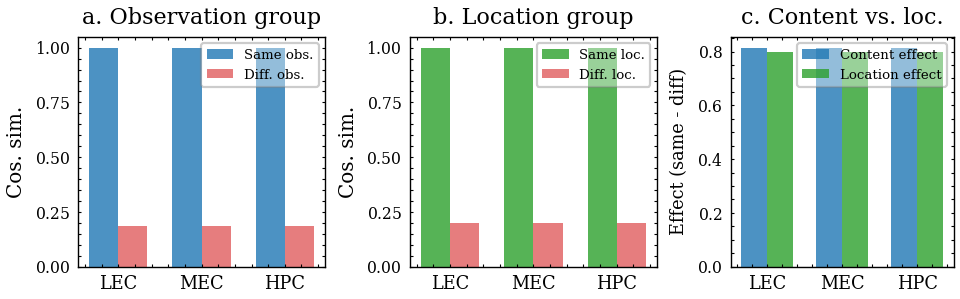

TEM v2 — lec_content_structure_rsa (case=arena_n1)


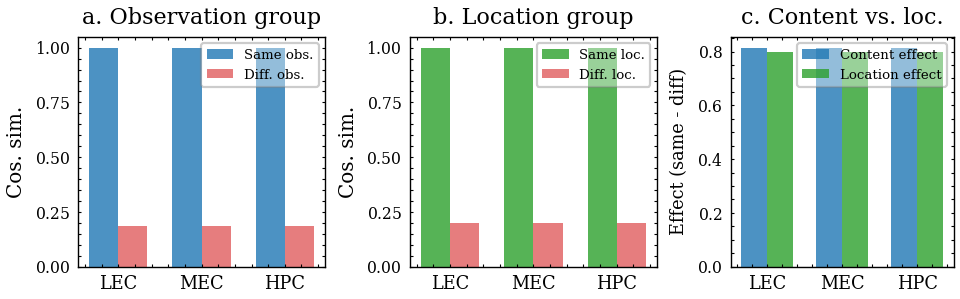

In [37]:
# --- LEC content structure RSA: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("lec_content_structure_rsa", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: lec_content_structure_rsa not available.")

> Figure 4: Content vs. location organization across TEM streams. Panel (a)
> shows the LEC similarity split by same/different observation, Panel (b) shows
> the MEC similarity split by same/different location, and Panel C plots the
> content effect vs location effect for all three streams (LEC, MEC, HPC).
> The relative magnitudes of these effects across streams can provide evidence
> for the functional roles of each stream in encoding content and structure.


**Interpretation guide.**  
Figure 4 tests the TEM factorisation directly. Panel A shows whether LEC states are more similar to each other when the same observation is present (blue bar) versus when different observations are present (red bar). A positive gap (blue > red) would indicate that LEC is organised by sensory content. Panel B shows the same comparison for location: green bars are mean similarity of states at the same arena location, red bars at different locations. A positive gap (green > red) would indicate organisation by spatial position.

Panel C summarises the dissociation as content effect and location effect per system. The TEM prediction is that LEC should show a stronger content effect than location effect, MEC the reverse, and HPC may show both. If all three systems show the same pattern, the predicted factorisation is not supported.

The main limitation to consider is that the RSA analysis uses cosine similarity between raw state vectors. This measures global representational overlap, not whether individual units are selectively tuned to content or structure. A system could appear to carry both content and location information in this metric even if individual units are highly specialised.


# MEC / g Structural-Stream

The TEM implementation includes an explicit MEC stream that performs path
integration and encodes relational/structural state before projection into
HPC. In the Tolman–Eichenbaum interpretation, this stream corresponds to
the structural state $g$.

This section evaluates the MEC structural stream in two ways. First, the
gridness metrics figure shows quantitative gridness scores and grid spacing
per frequency band, with representative autocorrelograms for top-scoring
cells. Second, the population autocorrelogram mosaic shows the full
distribution of spatial autocorrelation structure across all MEC cells,
ordered by gridness score.

Together, these figures test whether MEC encodes environment topology with
grid-like spatial periodicity — the signature of a reusable structural
representation — rather than producing an unstructured state vector.

### Variables inspected

Inputs inspected:

- `diagnostic/mec/location_mean`: per-frequency MEC cell activations,
  spatially binned into arena rate maps
- `location_id`: arena position annotation used for spatial binning
- `f_k`: frequency band index
- `t`: trajectory step (used to accumulate occupancy before spatial binning)

Typical shapes:

- Each frequency band: [n_cells, n_locations] after spatial binning
- Plotted value: spatially-binned mean activation (rate map), not raw
  temporal activation.


## Gridness metrics

This figure shows quantitative gridness scores and grid spacing per
frequency band, with representative rate-map and autocorrelogram examples
for top-gridness cells. It addresses whether MEC/g states exhibit
six-fold spatial periodicity — the hallmark of grid-like representations.

**What to look for:** Inspect three properties. First, whether gridness
scores in any frequency band consistently exceed zero — positive gridness
indicates six-fold rotational symmetry in the rate-map autocorrelogram.
Second, whether the top-gridness example cells show clear periodic
autocorrelograms, or whether high scores reflect artefactual correlations.
Third, whether grid spacing is consistent within each band and differs
between bands, which would suggest multiple spatial scales.


TEM v1 — mec_grid_metrics (case=arena_n1)


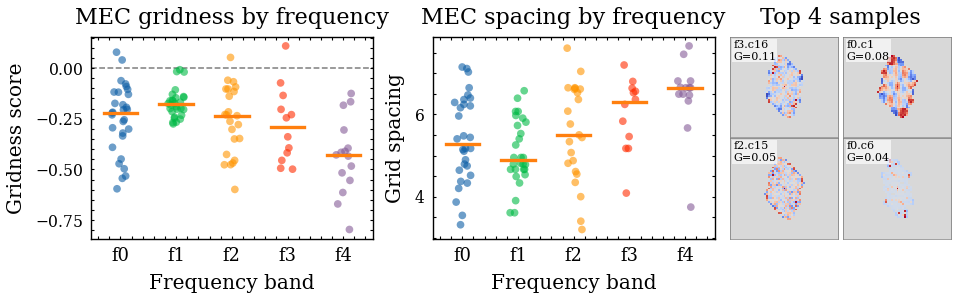


TEM v2 — mec_grid_metrics (case=arena_n1)


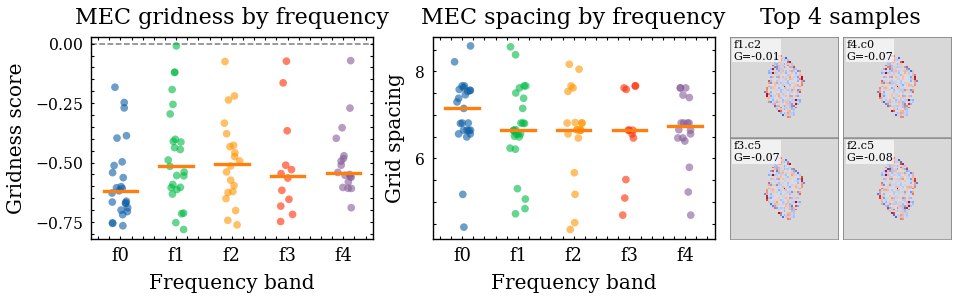

In [38]:
# --- MEC quantitative gridness metrics: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("mec_grid_metrics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mec_grid_metrics not available.")
    print()

> Figure 5: Quantitative gridness metrics for the MEC stream. Panel (a) shows
> gridness score distributions per frequency band. Panel (b) shows estimated
> grid spacing per frequency band. Panel (c) shows rate maps and
> autocorrelograms for the top-gridness cells in each band. The figure
> addresses whether MEC/g states encode environment topology with grid-like
> structure.


**Interpretation guide.**  
When reading Figure 5, consider what each panel reveals about the structural
stream. Panel (a) shows the distribution of gridness scores per frequency
band. Scores consistently above zero would indicate that cells in that band
exhibit six-fold rotational symmetry — consistent with hexagonal
periodicity. Negative or near-zero scores would indicate that rate maps
lack periodic spatial structure.

Panel (b) shows estimated grid spacing per band. If spacing is consistent
within a band and differs across bands, this would suggest that different
frequency bands encode spatial periodicity at different scales — a
multi-scale grid code. If spacing is uniform across all bands, the bands
may not be functionally differentiated.

Panel (c) shows the spatial rate maps and autocorrelograms for the
top-gridness cells. A cell with a periodic rate map would show a central
peak surrounded by six satellite peaks at approximately 60° intervals in
its autocorrelogram. If high-gridness cells show noisy or unstructured
autocorrelograms, the gridness metric may be capturing artefactual
correlations rather than genuine periodicity.

The main limitation is that these gridness scores are descriptive without a
shuffle or occupancy-matched null distribution. Scores above zero are
consistent with spatial periodicity but do not by themselves establish that
the model has learned grid-like representations in the biological sense.


## Population autocorrelogram mosaic

This figure shows the full population of rate-map autocorrelograms, ordered
by descending gridness score per frequency band. It complements the
quantitative gridness metrics by making spatial structure — or its absence —
visible across all MEC cells, not just the top-scoring examples.

**What to look for:** Inspect the range of autocorrelation structure across
the population. Cells near the top of each band should be checked for
visible six-fold symmetry. The transition from structured to unstructured
autocorrelograms across the population should be inspected for whether it
is gradual (consistent with a distributed code) or sharp (suggesting a
small subset of specialised cells). Compare across frequency bands: if one
band consistently produces more structured autocorrelograms than others,
that band may be the primary carrier of spatial periodicity.


TEM v1 — mec_autocorr_mosaic (case=arena_n1)


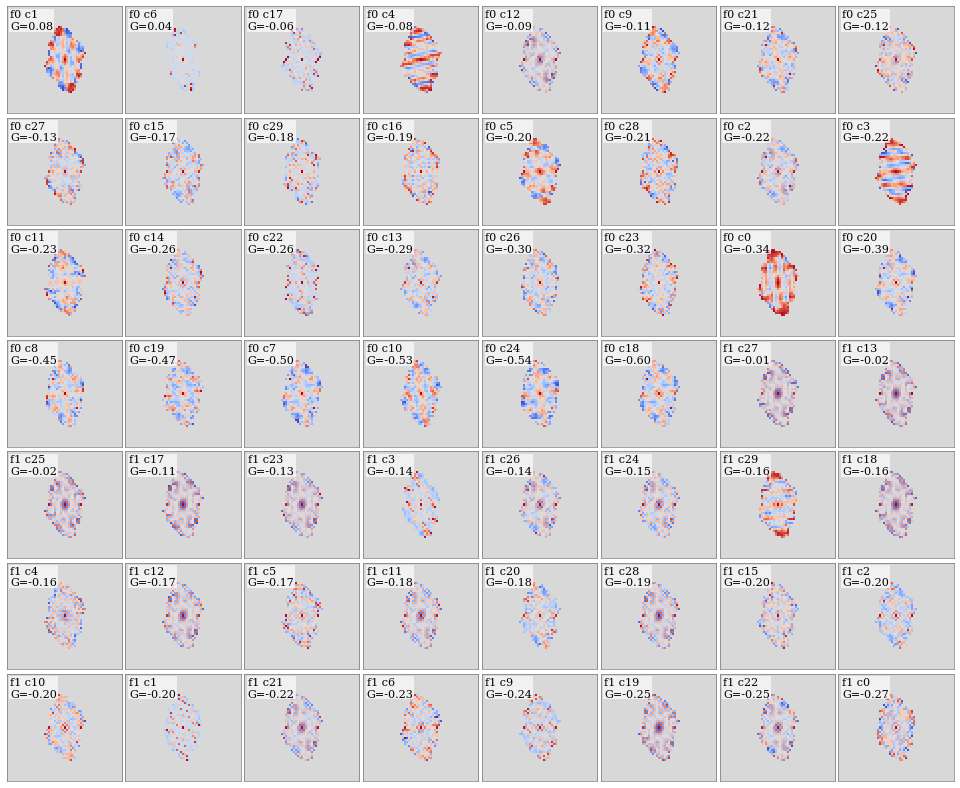

TEM v2 — mec_autocorr_mosaic (case=arena_n1)


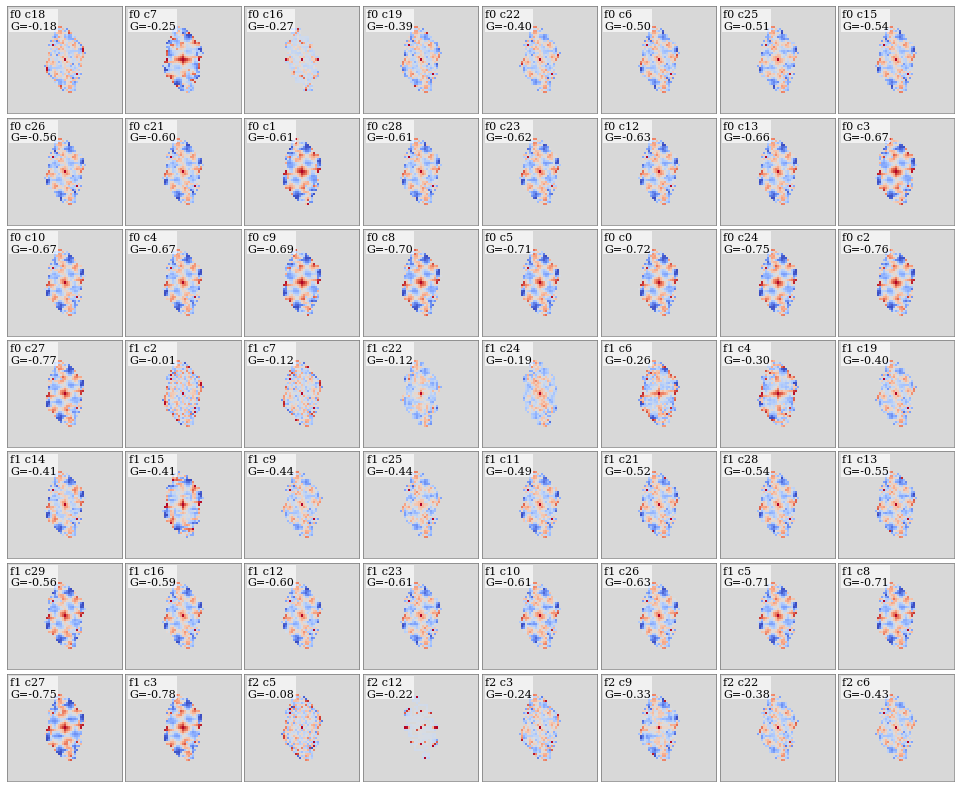

In [39]:
# --- MEC autocorrelogram mosaic: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("mec_autocorr_mosaic", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mec_autocorr_mosaic not available.")

> Figure 6: Population autocorrelogram mosaic for the MEC stream. Each tile
> is one cell's spatial autocorrelogram, ordered by descending gridness
> score within each frequency band. The mosaic complements the quantitative
> gridness metrics by showing the full population distribution of spatial
> autocorrelation structure.


**Interpretation guide.**  
When reading Figure 6, consider the population-level distribution of
autocorrelation structure. If grid-like periodicity is present, cells near
the top of each band would show visible six-fold symmetry in their
autocorrelograms — a central peak surrounded by six satellite peaks at
approximately 60° intervals. Cells near the bottom would show weaker or
absent periodic structure.

A smooth degradation from structured to unstructured autocorrelograms
across the population is consistent with a distributed grid code containing
a range of spatial tuning strengths. A sharp cutoff — where a few cells
show clear periodicity and the rest show noise — would suggest a small
specialised subpopulation rather than a distributed representation.

Comparing across frequency bands: if one band consistently produces more
structured autocorrelograms, that band may carry most of the model's
spatial periodicity. If no band shows visible periodicity, the gridness
scores may reflect artefactual correlations rather than genuine spatial
tuning.

The main limitation is the absence of a shuffle baseline. The mosaic is
descriptive and the reader should not over-interpret the presence of
periodic-looking autocorrelograms as definitive evidence of biological
grid-cell representations.


**Section conclusion — MEC/g.**  
This section provides the diagnostics needed to assess whether MEC/g states
exhibit grid-like spatial periodicity. Gridness scores can be compared
across frequency bands and between models; the presence of periodic
autocorrelograms can be inspected in the mosaic. The final conclusion should
be based on observed gridness values, the distribution across bands, and
comparison with a shuffle baseline (not yet available).


# HPC / p Place and Binding

The TEM implementation includes an explicit HPC stream that binds MEC
structural state (`g`) with LEC sensory content (`x`) into a conjunctive
episodic state. In the Tolman–Eichenbaum interpretation, this state
corresponds to the grounded hippocampal representation `p`.

This section evaluates the HPC conjunctive stream in two ways. First, the
place metrics figure shows quantitative spatial information scores,
field-center distributions, and representative rate-map examples for
top-scoring cells. Second, the population rate-map mosaic shows the full
distribution of spatial tuning across all HPC cells, ordered by spatial
information.

Together, these figures test whether HPC encodes place-like spatial
selectivity — the signature of a conjunctive representation that binds
structural position with sensory content — rather than producing an
unstructured or purely structural state vector.

### Variables inspected

Inputs inspected:

- `diagnostic/hpc/location_mean`: per-frequency HPC cell activations,
  spatially binned into arena rate maps
- `location_id`: arena position annotation used for spatial binning
- spatial information: per-cell measure of how concentrated firing is at
  specific locations
- `t`: trajectory step (used to accumulate occupancy before spatial binning)

Typical shapes:

- Each frequency band: [n_cells, n_locations] after spatial binning
- Plotted value: spatially-binned mean activation (rate map), not raw
  temporal activation.


## Place metrics

This figure shows quantitative spatial information scores, field-center
locations, and representative rate-map examples for top-scoring HPC cells.
It addresses whether HPC/p states exhibit localised spatial firing — the
hallmark of place-like conjunctive representations.

**What to look for:** Inspect three properties. First, whether spatial
information scores are shifted toward higher values, which would indicate
that many HPC cells have concentrated spatial firing fields. Second,
whether field centers are distributed across the full arena, which would
indicate population-level coverage of the environment. Third, whether the
top-scoring example cells show single localised firing fields — multi-field
or diffuse rate maps would indicate a different form of spatial tuning.


TEM v1 — hpc_place_metrics (case=arena_n1)


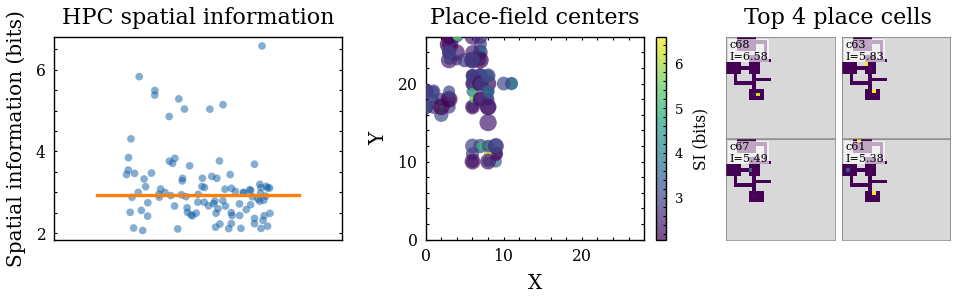


TEM v2 — hpc_place_metrics (case=arena_n1)


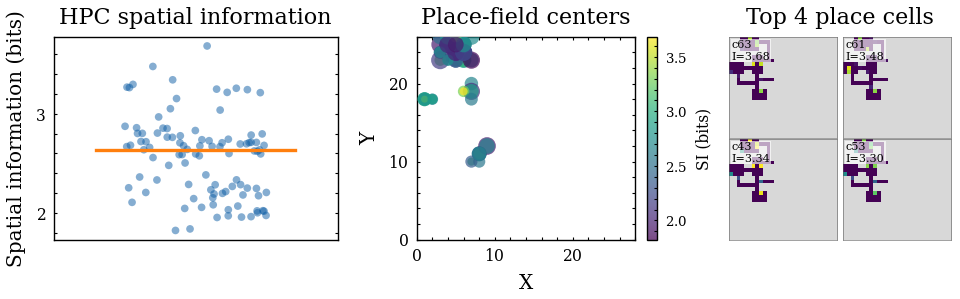

In [40]:
# --- HPC place metrics: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("hpc_place_metrics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: hpc_place_metrics not available.")
    print()

> Figure 7: Place metrics for the HPC stream. Panel (a) shows the spatial
> information (SI) distribution across HPC cells. Panel (b) shows
> field-center locations over the arena. Panel (c) shows rate-map examples
> for the top-scoring cells (2×2 mosaic). The figure addresses whether
> HPC/p states exhibit place-like spatial selectivity.


**Interpretation guide.**  
When reading Figure 7, consider what each panel reveals about the HPC
conjunctive state. Panel (a) shows the distribution of spatial information
(SI) scores across HPC cells — higher SI indicates that a cell's firing is
more concentrated at specific locations. A distribution shifted toward
higher values would indicate that many cells have place-like spatial
selectivity. A distribution clustered near zero would indicate that HPC
states are not spatially localised.

Panel (b) shows where each cell's preferred firing location falls in the
arena. Field centres distributed across the full arena would indicate that
the population collectively covers the environment. Clustering in specific
regions would suggest the representation is biased toward certain positions.

Panel (c) shows rate-map examples for the highest-SI cells. A single
localised firing field is the hallmark of a place-like representation;
multi-field or diffuse rate maps would indicate a different form of spatial
tuning.

The main limitation is the lack of a shuffle baseline for SI significance.
Additionally, place-like selectivity in `p` is consistent with the TEM
hypothesis but does not by itself establish conjunctive g-x binding, which
requires cross-stream decoding.


## Population rate-map mosaic

This figure shows the full population of rate maps, ordered by descending
spatial information. It complements the place metrics by making spatial
tuning — or its absence — visible across all HPC cells, not just the
top-scoring examples.

**What to look for:** Inspect the range of rate-map structure across the
population. High-SI cells (top rows) should be checked for single-field
place-like patterns. The transition from structured to unstructured rate
maps should be inspected for whether it is gradual (consistent with a
distributed place code) or sharp (suggesting a small specialised
subpopulation). Note that ordering by SI creates a favourable view: the
population always looks better at the top than the bottom. The reader
should check whether even high-SI cells show multi-field or irregular
patterns, which would indicate that spatial tuning in HPC may differ from
canonical place-cell responses.


TEM v1 — hpc_rate_map_mosaic (case=arena_n1)


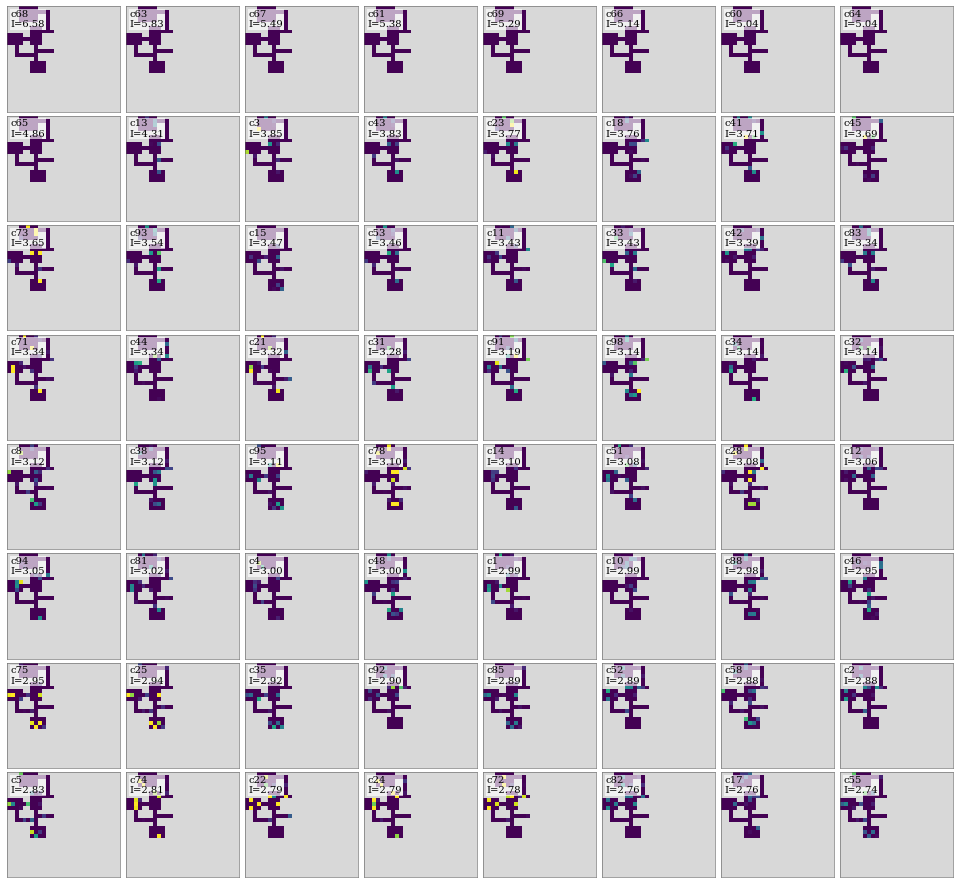


TEM v2 — hpc_rate_map_mosaic (case=arena_n1)


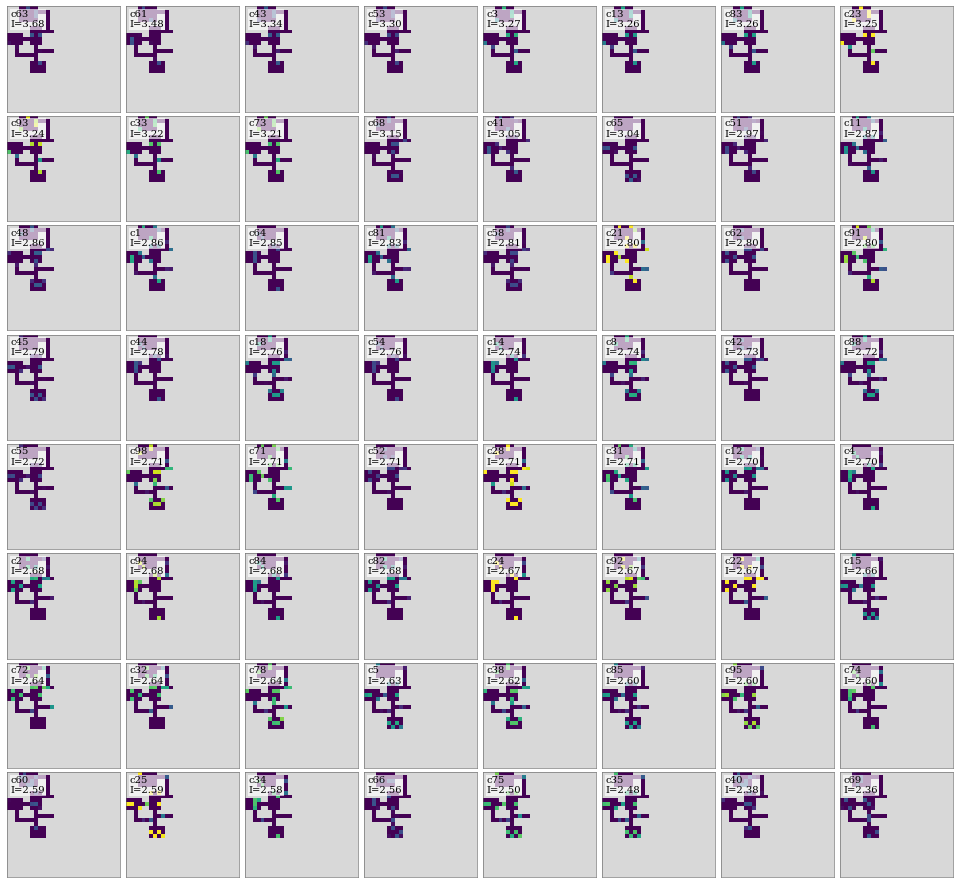

In [41]:
# --- HPC rate-map mosaic: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("hpc_rate_map_mosaic", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: hpc_rate_map_mosaic not available.")
    print()

> Figure 8: Population rate-map mosaic for the HPC stream. Each tile is one
> cell's spatially-binned rate map, ordered by descending spatial information.
> The mosaic complements the quantitative place metrics by showing the full
> population distribution of spatial tuning.


**Interpretation guide.**  
When reading Figure 8, consider the population-level distribution of rate-map
structure. If HPC is functioning as a conjunctive binding state, high-SI
cells would show clear single-field place-like patterns. Mid-range cells may
show broader or noisier fields. Low-SI cells may appear flat or unstructured.

A smooth gradient from structured to unstructured rate maps across the
population is consistent with a distributed place code. An abrupt transition
would suggest a small specialised subpopulation. If even high-SI cells show
multi-field or irregular patterns, the spatial tuning in HPC may differ from
canonical place-cell responses.

The main caveat is that the ordering by SI creates a favourable view: the
population always looks better at the top than the bottom. The transition
should be checked for whether it is gradual (expected for a distributed
code) or sharp (suggesting cherry-picking effects).

The main limitation is the absence of a shuffle baseline. The mosaic is
descriptive and the reader should not over-interpret place-like rate maps
as definitive evidence of biological place-cell representations.


**Section conclusion — HPC/p.**  
This section provides the diagnostics needed to assess whether HPC/p states
exhibit place-like spatial selectivity. Spatial information scores, field-center
distributions, and rate-map examples can be inspected to evaluate spatial tuning.
Full conjunctive binding of separable structural and content signals requires
cross-stream decoding or explicit conjunctivity diagnostics not yet implemented.
